Name : W. K. D. D. Senuruk  
## Fitting basics

Data points were generated from this referenced line  
Here, the need is to create a line which is suitable for the below data points

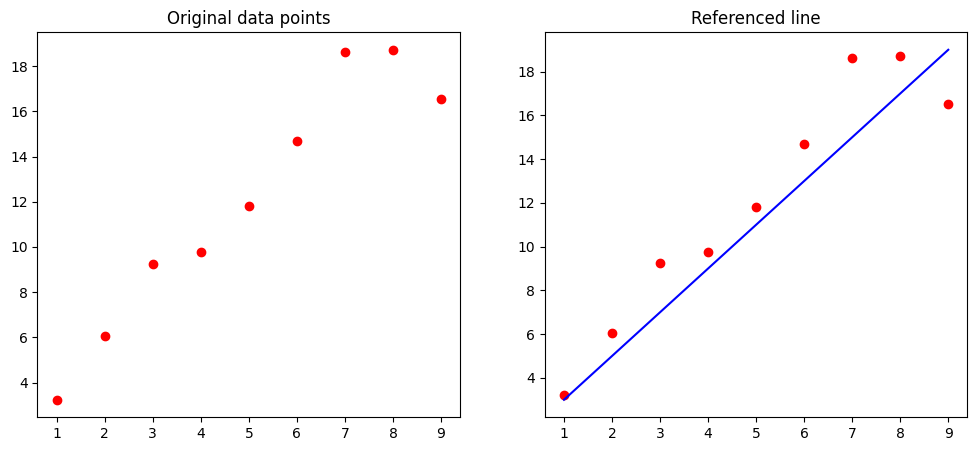

In [288]:
import matplotlib.pyplot as plt
import numpy as np

m = 2
c = 1
x = np.arange(1,10, 1)
n = 2.*np.random.randn(len(x))
o = np.zeros(x.shape)
# o[-1] = 20
y = m*x + c + n + o
y_r = m*x + c

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_r, color='blue')
ax[1].set_title("Referenced line")
plt.show()

#### Ordinary least-squares (OLS) line fitting

Here is my own implementation for OLS line fitting,  
Given a set of points (x_i, y_i), we want to fit a line:

$$
y = mx + b
$$

Our goal is to minimize the **sum of squared errors**:

$$
\text{Loss} = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

Minimum value of sum :  21.651212684089998
slope (m) :  1.91
y-intercept (b) :  2.53


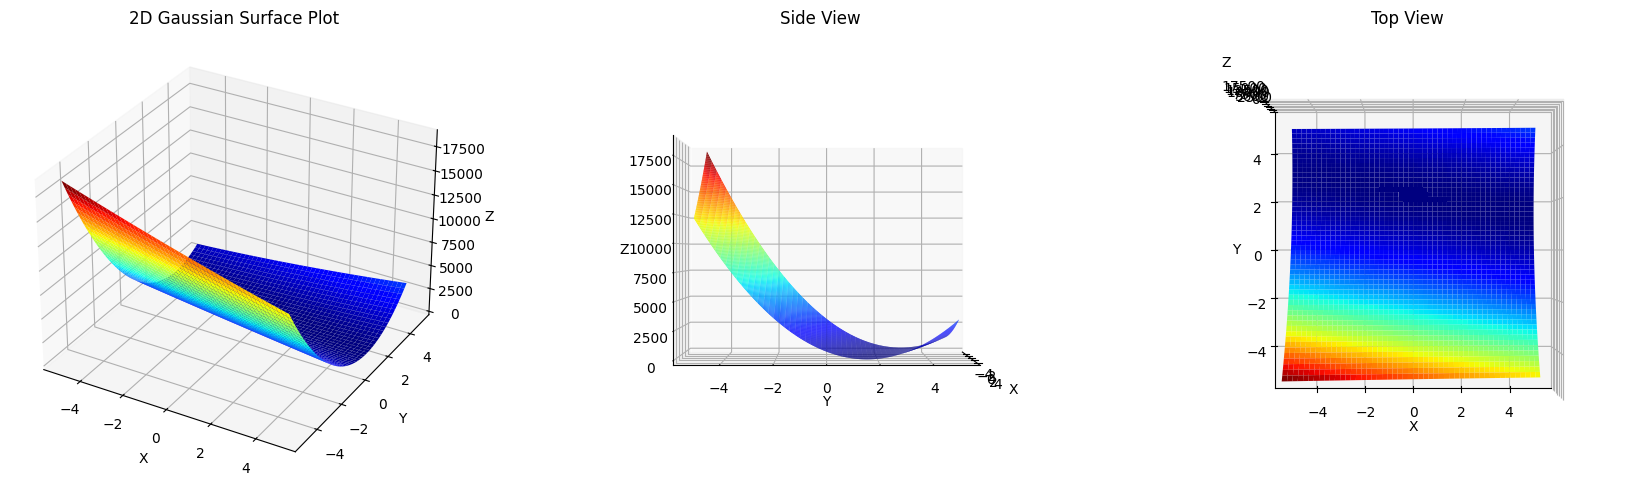

In [289]:
m = np.arange(-5, 5, 0.01)
b = np.arange(-5, 5, 0.01)
X, Y = np.meshgrid(m, b)

Z = np.zeros((m.shape[0], b.shape[0]), dtype=float)
for i in range(m.shape[0]):
    for j in range(b.shape[0]):
        Z[i][j] = np.sum([(y[k] - (m[i]*x[k] + b[j]))**2 for k in range(x.shape[0])])

print("Minimum value of sum : ", np.min(Z))
print("slope (m) : ", np.round(m[np.unravel_index(np.argmin(Z), Z.shape)[0]], 2))
print("y-intercept (b) : ", np.round(b[np.unravel_index(np.argmin(Z), Z.shape)[1]], 2))

fig = plt.figure(figsize=(18, 5))

# main view
ax = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='jet')
ax.set_title("2D Gaussian Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# side view
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='jet')
ax2.view_init(elev=0, azim=0)  # side view from the x-direction
ax2.set_title("Side View")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

# top view
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='jet')
ax3.view_init(elev=90, azim=-90)  # directly overhead
ax3.set_title("Top View")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()
plt.show()


#### Using matrices for OLS line fitting

 Let:

$$
\mathbf{A} =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
m \\
b
\end{bmatrix},
\quad
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

Then the model becomes:

$$
\mathbf{A} \mathbf{x} \approx \mathbf{y}
$$

We find the best "m" and "b" by minimizing the squared error:

$$
\min_{\mathbf{x}} \|\mathbf{A}\mathbf{x} - \mathbf{y}\|_2^2
$$

The **least-squares solution** is given by:

$$
\mathbf{x} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{y}
$$


slope (m):  1.915
y-intercept (b):  2.508


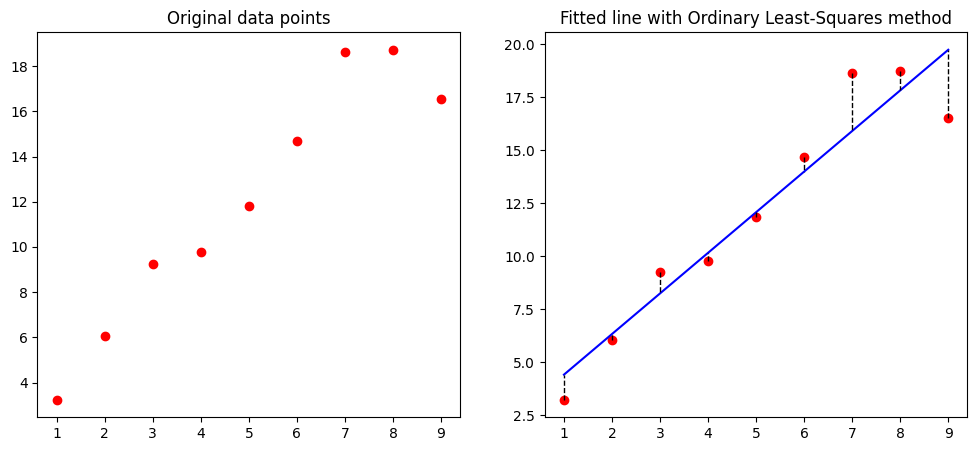

In [290]:
def ordinaryLeastSquares(x, y):
    A = np.vstack([x, np.ones_like(x)]).T
    y_ = np.reshape(y, (y.shape[0], 1))
    parameter_matrix = np.linalg.inv(A.T @ A) @ A.T @ y_
    a, b = parameter_matrix[0][0], parameter_matrix[1][0]
    return a, b

a, b = ordinaryLeastSquares(x, y)
y_n = a * x + b * np.ones_like(x)

print("slope (m): ", np.round(a, 3))
print("y-intercept (b): ", np.round(b, 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_n, color='blue')
for xi, yi, yi_pred in zip(x, y, y_n):
    ax[1].plot([xi, xi], [yi, yi_pred], 'k--', linewidth=1)
ax[1].set_title("Fitted line with Ordinary Least-Squares method")
plt.show()

#### Total least-squares (TLS) line fitting

Here is my own implementation for TLS line fitting,  
Given a set of points (x_i, y_i), we want to fit a line:

$$
y = mx + b \quad \quad \quad \quad \quad x = \frac{y - b}{m}
$$

Our goal is to minimize the **sum of squared orthogonal distances**:

$$
D_{vertical} = y_i - (mx_i + b) \quad \quad \quad \quad \quad
D_{horizontal} = x_i - \frac{y_i - b}{m}
$$

$$
D_{orthogonal} = \sin(\tan^{-1}(\frac{D_{horizontal}}{D_{vertical}})) \cdot D_{vertical}
$$

$$
\text{Loss} = \sum_{i=1}^{n} D_{orthogonal}^{2}
$$

Minimum value of sum :  4.370775569971137
slope (m) :  2.07
y-intercept (b) :  1.73


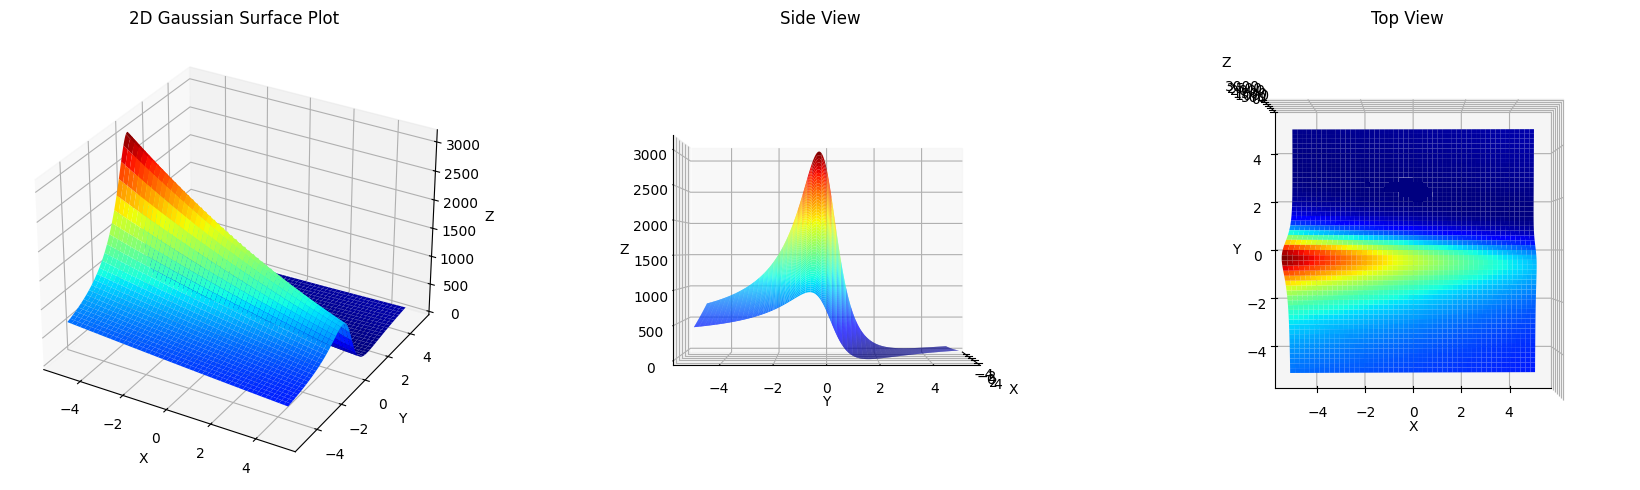

In [291]:
import warnings
warnings.filterwarnings("ignore")

m = np.arange(-5, 5, 0.01)
b = np.arange(-5, 5, 0.01)
X, Y = np.meshgrid(m, b)

Z = np.zeros((m.shape[0], b.shape[0]), dtype=float)
for i in range(m.shape[0]):
    for j in range(b.shape[0]):
        sum_of_squared_orthogonal_distances = 0
        for k in range(x.shape[0]):
            vertical_error = y[k] - (m[i]*x[k] + b[j])
            horizontal_error = x[k] - ((y[k] - b[j])/m[i])
            theta = np.atan([horizontal_error/vertical_error])
            squared_orthogonal_distance = (np.sin(theta)*vertical_error)**2
            sum_of_squared_orthogonal_distances += squared_orthogonal_distance
        Z[i][j] = sum_of_squared_orthogonal_distances

print("Minimum value of sum : ", np.min(Z))
print("slope (m) : ", np.round(m[np.unravel_index(np.argmin(Z), Z.shape)[0]], 2))
print("y-intercept (b) : ", np.round(b[np.unravel_index(np.argmin(Z), Z.shape)[1]], 2))

fig = plt.figure(figsize=(18, 5))

# main view
ax = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='jet')
ax.set_title("2D Gaussian Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# side view
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='jet')
ax2.view_init(elev=0, azim=0)  # side view from the x-direction
ax2.set_title("Side View")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

# top view
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='jet')
ax3.view_init(elev=90, azim=-90)  # directly overhead
ax3.set_title("Top View")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()
plt.show()


#### Using matrices for TLS line fitting

Given a set of points \((x_i, y_i)\), stack them into a matrix,

$$
X = \begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
\vdots & \vdots \\
x_n & y_n
\end{bmatrix}
$$

Center the data around the mean,

$$
X_{\text{centered}} = X - \bar{X} = X - (\bar{x}, \bar{y})
$$

Apply Singular Value Decomposition (SVD) to the centered matrix,

$$
X_{\text{centered}} = U \Sigma V^T
$$

where,
- \( U \) and \( V \) are orthogonal matrices
- \( Sigma \) is a diagonal matrix with singular values

The direction vector \((a, b)\) is the last row of \(V\) (i.e., the eigenvector corresponding to the smallest singular value),

$$
(a, b) = V_{[-1, :]}
$$

This \((a, b)\) is the **normal vector** to the best-fit line.  
Ensure the line passes through the mean,

$$
c = -(a \bar{x} + b \bar{y})
$$

Thus, the equation of the line is,

$$
a x + b y + c = 0
$$

$$
y = \frac{ -a x - c }{ b }
$$


slope (m) :  2.065
y-intercept (b) :  1.756


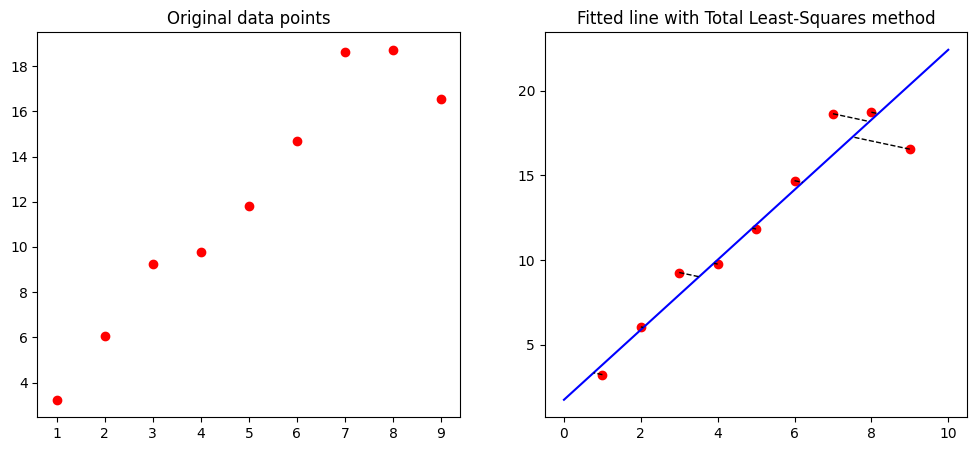

In [292]:
import numpy as np
import matplotlib.pyplot as plt

def totalLeastSquares(x, y):
    X = np.vstack((x, y)).T
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean
    U, S, VT = np.linalg.svd(X_centered)
    direction_vector = VT[-1, :]
    a, b = direction_vector
    c = -(a * X_mean[0] + b * X_mean[1])
    return a, b, c

a, b, c = totalLeastSquares(x, y)
x_fit = np.linspace(x.min() - 1, x.max() + 1, 100)
y_fit = (-a * x_fit - c) / b
y_tls = (-a * x - c) / b

print("slope (m) : ", np.round(-a/b, 3))
print("y-intercept (b) : ", np.round(-c/b, 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x_fit, y_fit, color='blue')
for xi, yi in zip(x, y):
    # Project point (xi, yi) onto the line
    d = (a * xi + b * yi + c) / (a**2 + b**2)
    x_proj = xi - a * d
    y_proj = yi - b * d
    plt.plot([xi, x_proj], [yi, y_proj], 'k--', linewidth=1)
ax[1].set_title("Fitted line with Total Least-Squares method")
plt.show()


#### Ordinary Least Squares (OLS) vs Total Least Squares (TLS)

$$
\begin{array}{|c|c|c|}
\hline
\textbf{Criterion} & \textbf{Ordinary Least Squares (OLS)} & \textbf{Total Least Squares (TLS)} \\
\hline
\text{Error in } X & \text{No} & \text{Yes} \\
\hline
\text{Error in } Y & \text{Yes} & \text{Yes} \\
\hline
\text{Easy to compute} & \text{Very easy (closed form)} & \text{Needs SVD} \\
\hline
\text{Assumes } X \text{ is perfect?} & \text{Yes} & \text{No} \\
\hline
\text{Residual type} & \text{Vertical distance} & \text{Orthogonal distance} \\
\hline
\end{array}
$$

#### RANSAC (Random Sample Consensus) line fitting

Here is my own implementation for RANSAC line fitting,  
For fitting a line, select two random points:  
     $$ (x_1, y_1), \quad (x_2, y_2) $$

Find the line passing through these two points.  
The line equation is:
     $$
     y = m x + b
     $$
Compute slope \( m \) and intercept \( b \):
     $$
     m = \frac{y_2 - y_1}{x_2 - x_1}
     $$
     $$
     b = y_1 - m x_1
     $$

For each point \( (x_i, y_i) \), compute the vertical distance to the model:
     $$
     r_i = | y_i - (m x_i + b) |
     $$

A point is an inlier if:
     $$
     r_i < \text{threshold}
     $$
Count the number of inliers.  
Repeat steps 1-4 for a fixed number of iterations \( N \).  
Choose the model (line) which has the maximum number of inliers.  
After selecting the best inliers, perform standard Least Squares fitting (OLS) **only on the inliers** to get a final accurate line.



slope (m) :  2.26
y-intercept (b) :  1.37


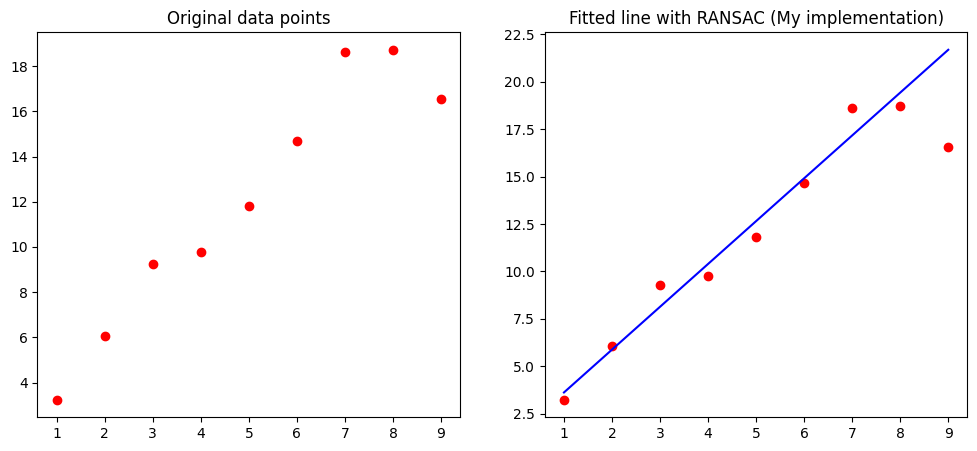

In [293]:
import random

N = 100
threshold = 2
m_b_list = []
inlier_count_list= []
inliers_list = []

for i in range(N):
    inlier_count = 0
    n1, n2 = random.sample(range(0, 9), 2)
    m_ = (y[n2] - y[n1])/(x[n2] - x[n1])
    b_ = y[n1] - m_*x[n1]
    inliers = []
    for k in range(x.shape[0]):
        r_k = np.abs(y[k] - (m_*x[k] + b_))
        if (r_k < threshold):
            inlier_count += 1
            inliers.append(k)
    m_b_list.append([m_, b_])
    inlier_count_list.append(inlier_count)
    inliers_list.append(inliers)
index = np.where(inlier_count_list == np.max(inlier_count_list))[0][0]
inliers_list[index]

x_new = np.array([x[j] for j in inliers_list[index]])
y_new = np.array([y[j] for j in inliers_list[index]])
a, b = ordinaryLeastSquares(x_new, y_new)
y_new_pred = a * x + b

print("slope (m) : ", np.round(a, 2))
print("y-intercept (b) : ", np.round(b, 2))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_new_pred, color='blue')
ax[1].set_title("Fitted line with RANSAC (My implementation)")
plt.show()

#### Using RANSAC regression model in scikit-learn

slope (m) :  2.257
y-intercept (b) :  1.366


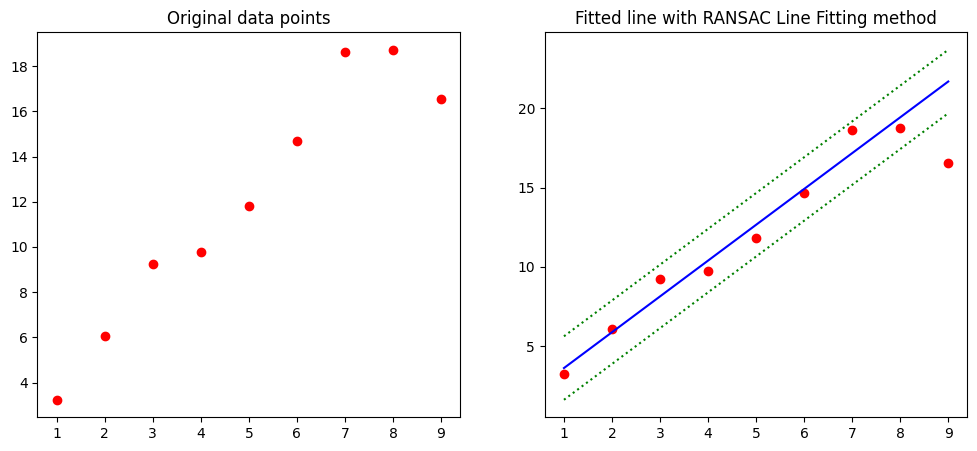

In [294]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

def ransac(x, y):
    x_ = x.reshape(-1, 1)
    ransac = RANSACRegressor(LinearRegression(), residual_threshold=2.0, random_state=0)
    ransac.fit(x_, y)
    m_ransac = ransac.estimator_.coef_[0]
    b_ransac = ransac.estimator_.intercept_
    return m_ransac, b_ransac

m_ransac, b_ransac = ransac(x, y)

print("slope (m) : ", np.round(m_ransac, 3))
print("y-intercept (b) : ", np.round(b_ransac, 3))

y_ = m_ransac*x + b_ransac

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_, color='blue')
ax[1].plot(x, y_ + 2, color='green', linestyle='dotted', label='+ Threshold')
ax[1].plot(x, y_ - 2, color='green', linestyle='dotted', label='- Threshold')
ax[1].set_title("Fitted line with RANSAC Line Fitting method")
plt.show()

#### Comparison of OLS, TLS & RANSAC line fittings with referenced line

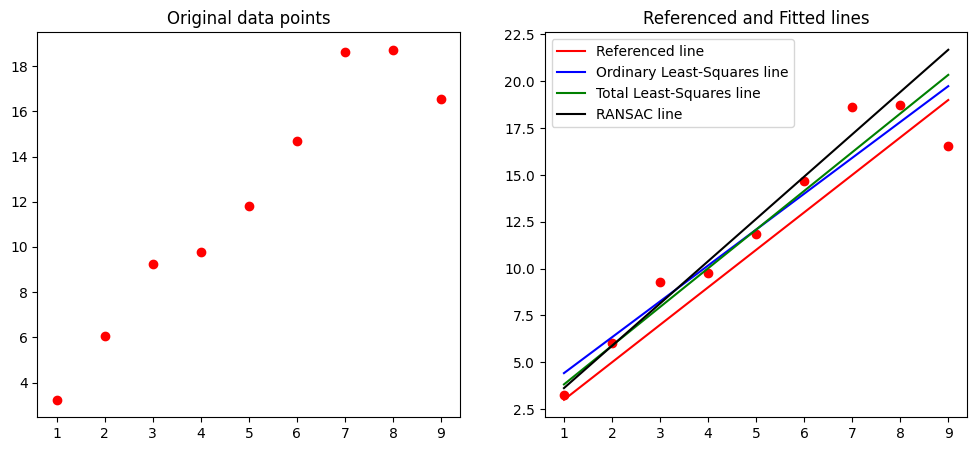

In [295]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_r, color='red', label="Referenced line")
ax[1].plot(x, y_n, color='blue', label="Ordinary Least-Squares line")
ax[1].plot(x, y_tls, color='green', label="Total Least-Squares line")
ax[1].plot(x, y_, color='black', label="RANSAC line")
ax[1].set_title("Referenced and Fitted lines")
plt.legend()
plt.show()

#### Comparison of OLS, TLS & RANSAC line fittings with referenced line when outliers exists

RANSAC is robust to outliers.  
But OLS & TLS are not robust against outliers. They differ so much when an outlier is present.

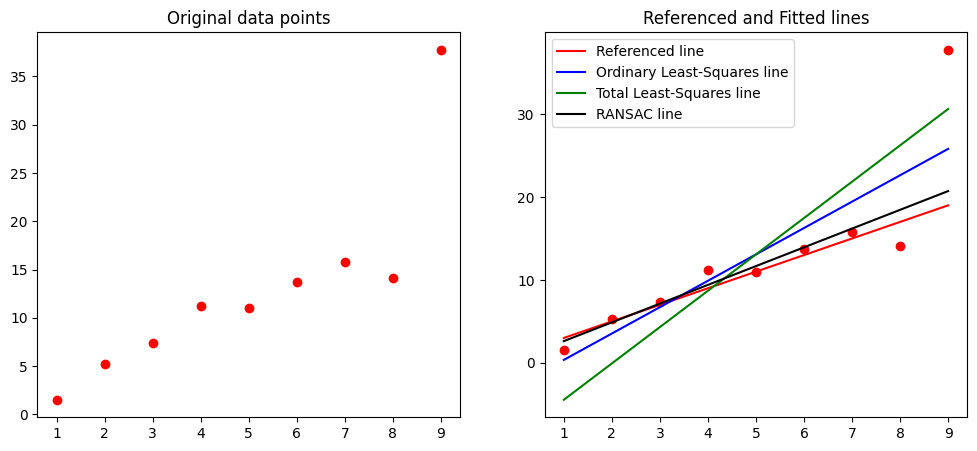

In [296]:
m = 2
c = 1
x = np.arange(1,10, 1)
n = 2.*np.random.randn(len(x))
o = np.zeros(x.shape)
o[-1] = 20
y = m*x + c + n + o
y_r = m*x + c

a, b = ordinaryLeastSquares(x, y)
y_ols = a*x + b

a, b, c = totalLeastSquares(x, y)
y_tls = (-a*x - c)/b

a, b = ransac(x, y)
y_ransac = a*x + b

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_r, color='red', label="Referenced line")
ax[1].plot(x, y_ols, color='blue', label="Ordinary Least-Squares line")
ax[1].plot(x, y_tls, color='green', label="Total Least-Squares line")
ax[1].plot(x, y_ransac, color='black', label="RANSAC line")
ax[1].set_title("Referenced and Fitted lines")
plt.legend()
plt.show()